# 非線形バネへのC/GMRESの適用

アルゴリズム理解のため非線形バネに対してC/GMRESを適用する。

制約は状態方程式のみのものである。

## 1質点モデル

<img src ="images/one-degree-nonlinear-spring.png" style="width:30%;"/>

### 運動方程式

バネの復元力 $F(x)$ は次のように非線形性を持つとする。

$$
F(x) = kx(t) + k_3 x(t)^3
$$

$x(t)$ の方向に力 $u(t)$ を質点 $m$ へ加えた場合、次の運動方程式になる。

$$
m\ddot{x}(t) = u(t) - kx(t) - k_3 x(t)^3
$$

### 状態方程式

状態 $X(t)$ を以下のように定義する。

$$
X(t) = [x(t), v(t)]^T
$$

運動方程式を以下のようにまとめる。

$$
\begin{aligned}
\dot{x}(t) &= v(t) \\
\dot{v}(t) &= \frac{1}{m}\left( u(t) - k x(t) - k_3 x(t)^3 \right) 
\end{aligned}
$$

ここから、状態方程式 $\dot{X} = f(X, u)$ は次のようになる。

$$
\frac{d}{dt}
\begin{bmatrix}
x(t) \\ v(t)
\end{bmatrix}
= \begin{bmatrix}
v(t) \\ \dfrac{1}{m}\left( u(t) - k x(t) - k_3 x(t)^3 \right)
\end{bmatrix}
$$

### 拡大評価関数とコスト

拡大評価関数 $\bar{J}$ は次の式である。 

$$
\bar{J} = \Phi(X(T)) + \int_0^T \left[ L(X,u) + \lambda^T \ \left( f(X,u) - \dot{X} \right) \right] dt
$$

位置の目標値を$x_{ref}$ とするように、ランニングコスト$L(X,u)$と終端コスト$\Phi(X(T))$ を設定する。


##### ランニングコスト $L$

ランニングコスト $L(X,u)$ は次のように設定する。

$$
L(X,u) = \frac{1}{2} q_x(x(t) - x_{ref})^2 + \frac{1}{2} q_v v(t)^2 + \frac{1}{2} r u(t)^2
$$

$\bar{J}$の最小化問題になるため、ランニングコスト $L(X,u)$ のそれぞれの意味は次のようになる。

- 第1項目: 位置の目標値との誤差を小さくする
- 第2項目: 速度を大きくしない
- 第3項目: 入力を大きくしない

##### 終端コスト $\Phi$

終端コスト $\Phi(X(T))$ は次のように設定する。終端はこれまでの制御入力により到達した状態であるため、制御入力は終端コストではなく、ランニングコストで評価する。

$$
\Phi(X(T)) = \frac{1}{2}q_{xT}(x(T) - x_{ref})^2 + \frac{1}{2}q_{vT}v(T)^2
$$

$\bar{J}$の最小化問題になるため、終端コスト $\Phi(X(T))$ のそれぞれの意味は次のようになる。

- 第1項目: 時刻$T$ における位置と目標位置との誤差を小さくする
- 第2項目: 時刻$T$ における速度を大きくしない

##### 随伴変数　$\lambda$

$\lambda$は状態方程式制約$f(X,u) - \dot{X}$ と内積をとり、$\lambda^T (f(X,u) - \dot{X}) $がスカラーとなるように設定する。状態$X$は2変数であるため、$\lambda$を次のように設定する。

$$
\lambda = [\lambda_x, \lambda_v]^T
$$


### PMP 条件

Hamiltonian $H$ は次の式である。

$$
H(X,u,\lambda) = L(X, u) + \lambda^T f(X, u)
$$

具体的に$H$を構成すると次のようになる。

$$
H = \frac{1}{2} q_x(x(t) - x_{ref})^2 + \frac{1}{2} q_v v(t)^2 + \frac{1}{2} r u(t)^2 + \lambda_x v(t) + \frac{\lambda_v}{m}\left(u(t) - k x(t) - k_3 x(t)^3  \right)
$$

PMP条件を構成するため、$H$ を$X,u$で偏微分、$\Phi$を$X(T)$ で偏微分を行う。また、$H_\lambda = f(X,u)$ である。

$$
\begin{aligned}
H_X &= \frac{\partial H}{\partial X} = \begin{bmatrix} \partial H / \partial x \\ \partial H / \partial v \end{bmatrix} =
\begin{bmatrix}
q_x(x(t) - x_{ref}) - \lambda_v/m \ \left( k + 3 k_3 x(t)^2 \right) \\
q_v v(t) + \lambda_x 
\end{bmatrix} \\
H_u &= \frac{\partial H}{\partial u} = r u(t) + \frac{\lambda_v}{m} \\
\Phi_X &= \frac{\partial \Phi}{\partial X} = \begin{bmatrix} \partial \Phi / \partial x \\ \partial \Phi / \partial v \end{bmatrix} =
\begin{bmatrix}
q_{xT}(x(T) - x_{ref}) \\
q_{vT} v(T)
\end{bmatrix} 
\end{aligned}
$$



$H$を用いて、PMP条件は次のようになる。

$$
\begin{array}{l}
\dot{X} = H_\lambda \\
\dot{\lambda} = - H_X \\
H_u = 0 \\
\lambda(T) = \Phi_X(X(T)) \\
\end{array}
$$ 

よって1質点の非線形バネモデルにおけるPMP条件の式は以下となる。

状態方程式

$$
\boxed{
\frac{d}{dt}
\begin{bmatrix}
x(t) \\ v(t)
\end{bmatrix}
= \begin{bmatrix}
v(t) \\ \dfrac{1}{m}\left( u(t) - k x(t) - k_3 x(t)^3 \right)
\end{bmatrix}
}
$$

随伴方程式

$$
\boxed{
\frac{d}{dt}
\begin{bmatrix}
\lambda_x \\ \lambda_v
\end{bmatrix}
=-\begin{bmatrix}
q_x(x(t) - x_{ref}) - \lambda_v/m \ \left( k + 3 k_3 x(t)^2 \right) \\
q_v v(t) + \lambda_x 
\end{bmatrix}
}
$$

停留条件

$$
\boxed{
r u(t) + \frac{\lambda_v}{m} = 0
}
$$

終端条件

$$
\boxed{
\begin{bmatrix}
\lambda_x(T) \\ \lambda_v(T)
\end{bmatrix} =
\begin{bmatrix}
q_{xT}(x(T) - x_{ref}) \\
q_{vT} v(T)
\end{bmatrix} 
}
$$

### 状態 $X$ 随伴変数 $\lambda$ の時系列の計算式と停留条件式 $F$ の構成

制御入力列 $U(t_k)$ 、状態の初期値 $X[0]$、予測ホライゾンの長さ$T(t_k)=T_f(1 - \exp(-\alpha t_k))$ の$t_k$を設定値として時系列を計算する。

予測ホライゾンのステップ幅 $h(t_k)$ は $T(t_k)$の分割数 $N$ より以下のようになる。

$$
h(t_k) = T(t_k) / N
$$

以下の式は上から順に、状態$X[n]$、終端状態 $\lambda[N]$、随伴変数 $\lambda[n]$ に関する。

$$
\begin{aligned}
\begin{bmatrix}
x[n+1] \\ v[n+1]
\end{bmatrix} &=
\begin{bmatrix}
x[n] \\ v[n]
\end{bmatrix} +
h\begin{bmatrix}
v[n] \\ \dfrac{1}{m}\left( u_n(t_k) - k x[n] - k_3 x[n]^3 \right)
\end{bmatrix}, \quad n = 0, \cdots , N-1 \\
\begin{bmatrix}
\lambda_x[N] \\ \lambda_v[N]
\end{bmatrix} &=
\begin{bmatrix}
q_{xT}(x[N] - x_{ref}) \\
q_{vT} v[N]
\end{bmatrix} \\
\begin{bmatrix}
\lambda_x[n] \\ \lambda_v[n]
\end{bmatrix} &=\begin{bmatrix}
\lambda_x[n+1] \\ \lambda_v[n+1]
\end{bmatrix}
+h\begin{bmatrix}
q_x(x[n] - x_{ref}) - \lambda_v[n+1]/m \ \left( k + 3 k_3 x[n]^2 \right) \\
q_v v[n] + \lambda_x[n+1] 
\end{bmatrix} , \quad n = N-1, \cdots , 1
\end{aligned}
$$

上記を用いて、停留条件式 $F(X(t_k), U(t_k))$ を以下のように構成する。

$$
F(X(t_k), U(t_k)) = 
\begin{bmatrix}
r u_0(t_k) + \dfrac{\lambda_v[1]}{m} \\
\vdots \\
r u_{N-1}(t_k) + \dfrac{\lambda_v[N]}{m} \\
\end{bmatrix} = 0
$$

また、この時系列から$F$を構成する計算はC/GMRESの実行中に何度も行われる。そのため

$$
F(U(t_k), X(t_k), t_k)
$$

を関数として定義する。これは、$U(t_k)$ に制御入力列、$X(t_k)$ に実時間 $t_k$ における現在状態を与え、それを予測区間の初期状態$X[0]$として使用する、$t_k$を$T(t_k)$ を計算する入力として与えれれば、それをもとに停留条件の式 $F(U(t_k), X(t_k), t_k)$ を構成する、という意味である。

### 初期制御入力 $u(0)$ の計算

$T(0)=0$ として解析的に $u(0)$ を求める。

停留条件を$T(0)=0$ で構成すると以下の式となる。

$$
r u(0) + \frac{q_{vT} v(0)}{m} = 0 \rightarrow u_0 = -\frac{q_{vT}v(0)}{r\ m} 
$$

ここから、初期状態 $X(0)$ を取得すれば、$u(0)$が計算できるといえる。

$(x(0) - x_{ref})$ の状態を考慮していないが、$u(0)$は求まる。これは $u(t)$ は以下の加速度側の運動方程式にあり、

$$
\dot{v} = \frac{1}{m}\left( u(t) - k x(t) - k_3 x(t)^3 \right)
$$

かつ、Hamiltonian $H$ は以下であるため、

$$
H = L + \lambda_x \dot{x} + \lambda_v \dot{v}
$$

$H$ の $u$ による偏微分は以下のようになり、$u(t)$ に関しては $\lambda_v$ のみが関係するためである。

$$
H_u = r u(t) + \frac{\lambda_v}{m}
$$

$H_u$ には $x$ に対応する $\lambda_x$ が直接出てこない。これは

$$
u \rightarrow \dot{v} \rightarrow v \rightarrow \dot{x} \rightarrow x
$$

という構造になっているためである。

$T(0)=0$ では予測区間が存在しないため、入力$u$によって速度$v$が変化し、その速度変化がさに将来の位置変化へ伝わる過程を予測する時間がない。そのため、初期$u(0)$を計算する問題では位置誤差 $x(0) - x_{ref}$ が $H_u$ に直接現れない。

$T(t)$が$0$から有限長へ伸びると、予測区間内の状態・随伴変数の時系列が計算され、位置誤差の影響が随伴変数を介して停留条件 $H_u$ に反映される。


ここまでがC/GMRESを計算するために必要な設定である。

これらの計算を用いてC/GMRESの制御ループを以下のように実行する。

# C/GMRESの計算

以下のStep 1 から Step 8を繰り返す。

### Step 1 状態取得

制御対象の状態 $X(t_k)$ を取得する。

### Step 2 制御入力列の更新

制御入力列 $U(t_k) \ \in \mathbb{R}^{N}$ は前回のC/GMRESで計算された値を用いる。

$t_0$ の場合、$X(t_0)$ を用いて $u(0)$ を計算し、$U(t_0) \ \in \mathbb{R}^{N}$の制御入力列を構成する。

$$
U(t_0) = [u(0), \cdots , u(0)]^T
$$

### Step 3 制御対象へ制御入力を出力

制御対象へ 制御入力列 $U(t_k)$ の第一要素 $u_0(t_k)$を出力する。

### Step 4 状態$\dot{X}$の計算

$\dot{X}(t_k) = f(X(t_k), u_0(t_k))$ を計算する。

今回の場合、以下の状態方程式を計算する。

$$
\frac{d}{dt}
\begin{bmatrix}
x(t_k) \\ v(t_k)
\end{bmatrix}
= \begin{bmatrix}
v(t_k) \\ \dfrac{1}{m}\left( u_0(t_k) - k x(t_k) - k_3 x(t_k)^3 \right)
\end{bmatrix}
$$

### Step 5 停留条件の計算

$F(U(t_k), X(t_k), t_k)$ を計算する。

### Step 6 右辺 $b_k$ の計算

GMRESの右辺に渡す $b_k$ を計算する。

$F(U(t_k) , X(t_k) + \varepsilon \dot{X}(t_k) , t_k + \varepsilon)$ を計算する。

$$
b_k = - \frac{F(U(t_k) , X(t_k) + \varepsilon \dot{X}(t_k) , t_k + \varepsilon) - F(U(t_k), X(t_k), t_k)}{\varepsilon} - \zeta F(U(t_k), X(t_k), t_k)
$$

### Step 7 GMRESの計算

#### Step 7-1 初期残差の計算

初期残差 $r_0$ の計算に用いる初期解を $\dot{U}^{(0)}(t_k)$を前回の制御ループで計算した $\dot{U}(t_{k-1})$ とする。

$t_0$ の場合、$\dot{U}^{(0)}(t_0)=0$ とする。

$t_k$ の場合、$r_0$ を計算する $F_U \dot{U}^{(0)}(t_k)$ を以下で計算する。

$$
F_U \dot{U}^{(0)}(t_k) = \frac{F(U(t_k) + \varepsilon \dot{U}^{(0)}(t_{k}), X(t_k), t_k) - F(U(t_k), X(t_k), t_k)}{ \varepsilon}
$$

以上より、初期残差を計算する。

$$
r_0 = b_k - F_U \dot{U}^{(0)}(t_k)
$$

#### Step 7-2 直交基底 $v_1$ の計算

$$
v_1 = r_ 0 / \beta , \quad \beta = ||r_0||
$$

#### Step 7-3 Arnoldi法 Step m (m=$1, \cdots $)

$$
\begin{aligned}
F_U(t_k) v_m &= \frac{F(U(t_k) + \varepsilon v_m, X(t_k), t_k) - F(U(t_k), X(t_k), t_k)}{\varepsilon} \\
h_{i, m} &= v_i^T F_U(t_k) v_m \quad (i = 1, \cdots , m) \\
w &= F_U(t_k) v_m - \sum_{i=1}^{m} h_{i,m} v_i \\
h_{m+1, m} &= ||w|| \\
v_{m+1} &= w / h_{m+1, m}
\end{aligned}
$$

この後、これまでのGivens回転を今回構成される 上ヘッセンベルグ行列の列へ適用し、上三角行列を作る。

残差 $g$ が目標よりも小さければ 最小二乗問題を解き、$Y_m$ を計算し、Arnoldi法の繰り返しを終了する。
そうでなければ、Arnoldi法のStep を繰り返す。

#### Step 7-4 $\dot{U}(t_k)$ の近似解を計算

Arnoldi法が停止した Step m では Krylov部分空間の直交基底 $V_m$ と、$Y_m$ が求まっている。
これを用いて、$\dot{U}(t_k)$ を次のように構成する。

$$
\dot{U}(t_k) = \dot{U}^{(0)}(t_k) + V_m Y_m
$$

### Step 8 次の制御入力列 $U(t_{k+1})$ を計算

求めた $\dot{U}(t_k)$ から、次の時刻の $U(t_{k+1})$ を以下の方法で計算する。

$$
U(t_{k+1}) = U(t_k) + \Delta t \  \dot{U}(t_k) , \quad \Delta t = t_{k+1} - t_{k}
$$


# 実装

PythonによるC/GMRESの実装を行う

In [1]:
from dataclasses import dataclass
import numpy as np

@dataclass
class Parameters:    
    # 非線形バネモデル
    m: float = 1.0  # 質量
    k: float = 1.0  # バネ定数
    k3: float = 2.0  # 3次のバネ定数
    
    # 目標位置
    x_target: float = 1.0  # 目標位置[m]
    
    # ランニングコストの重み
    qx: float = 1.0  # 状態 位置の重み
    qv: float = 1.0  # 状態 速度の重み
    r: float = 0.1  # 制御入力の重み
    
    # 終端コストの重み
    qxt: float = 10.0  # 終端状態 位置の重み
    qvt: float = 10.0  # 終端状態 速度の重み
    
    # 予測ホライゾン関連
    Tf: float = 5.0  # 予測ホライゾンの最終長さ
    Ta: float = 0.1  # 予測ホライゾンの収束の速さ(大きいほど早く収束する)
    N: int = 50  # 予測ホライゾンの分割数

    # 有限差分の計算項目
    eps: float = 1e-3 # 

    # 計算の安定性に関する項目
    zeta: float = 10.0 # 停留条件への追従
    
    # 計算周期(コントローラの更新周期)
    dt: float = 0.01 # [s]

class C_GMRES:
    def __init__(self, params: Parameters):
        self.params = params
        self.prev_U = None
        self.prev_dU = None
        self.prev_t = 0

    # 初期制御入力の計算
    def initial_control_input(self, X0):
        # 初期制御入力をゼロに設定
        U = np.zeros(self.params.N)
        u0 = -self.params.qvt*X0[1]/(self.params.r * self.params.m)  # 初期制御入力の計算
        for i in range(self.params.N):
            U[i] = u0
        return U

    # 状態方程式
    def state_equation(self, X, u):
        m = self.params.m  # 質量
        k = self.params.k  # バネ定数
        k3 = self.params.k3  # 3次のバネ定数
        dx = X[1]
        dv = (u - k * X[0] - k3 * X[0]**3) / m
        return np.array([dx, dv], dtype=float)
    
    # PMP 停留条件式
    def calc_F(self, U, X, t):
        # 予測ホライゾンの長さを計算
        T = self.params.Tf * (1 - np.exp(-self.params.Ta * t))
        # ステップ幅を計算
        h = T / self.params.N
        # 状態の時系列設定
        Xs = np.zeros((self.params.N + 1, 2))
        # 随伴変数の時系列設定
        Ls = np.zeros((self.params.N + 1, 2))
        
        # 状態の初期値を設定
        Xs[0] = X
        
        # 状態方程式を用いて状態の時系列を計算
        for i in range(self.params.N):
            Xs[i + 1] = Xs[i] + h * np.array(self.state_equation(Xs[i], U[i]))
            
        # 終端条件を計算
        Ls[-1,0] = self.params.qxt * (Xs[-1,0] - self.params.x_target)
        Ls[-1,1] = self.params.qvt * Xs[-1,1]
        
        # 随伴方程式を用いて随伴変数の時系列を計算
        for i in range(self.params.N - 1, -1, -1):
            dL = np.array([-self.params.qx * (Xs[i,0] - self.params.x_target) + Ls[i+1,1]/self.params.m * (self.params.k + 3 * self.params.k3 * Xs[i,0]**2),
                        -self.params.qv * Xs[i,1] - Ls[i + 1,0]])
            Ls[i] = Ls[i + 1] - h * dL
        
        # 停留条件式の構成
        F = np.zeros(self.params.N)
        for i in range(self.params.N):
            F[i] = self.params.r * U[i] + Ls[i+1,1]/self.params.m
            
        return F

    # step 7 GMRES
    def gmres(self, X, t, max_iter:int = 50, rtol:float=1e-6, atol:float=1e-8):

        # 変数定義
        self.n = len(self.U)
        self.g = np.zeros(self.n+1) # 右辺の構成
        self.R = np.zeros((self.n, self.n)) # 上三角行列の構成
        self.c = np.zeros(self.n) # Givens回転 c の配列
        self.s = np.zeros(self.n) # Givens回転 s の配列
        self.V = np.zeros((self.n, self.n+1)) # Klynov部分空間の直交基底

        # step 7-1 初期残差の計算
        if self.prev_dU is None:
            self.dU_0 = np.zeros(self.n)
            self.FudU = np.zeros(self.n)
        else:
            self.dU_0 = self.prev_dU
            self.FudU = (self.calc_F(self.U + self.params.eps * self.dU_0, self.X_future, self.t_future) - self.F_future)/self.params.eps

        self.r0=self.bk - self.FudU

        self.beta = np.linalg.norm(self.r0)
        if self.beta < atol: # 絶対誤差が十分小さい場合
            return self.dU_0.copy()
        
        # step 7-2 直交基底 v1 の計算
        v1 = self.r0 / self.beta
        self.V[:,0] = v1

        self.g[0] = self.beta

        max_iter = min(max_iter, self.n)

        for k in range(max_iter):
            # step 7-3 Arnoldi法 step m
            
            #修正グラムシュミット法
            FuVm = (self.calc_F(self.U + self.params.eps * self.V[:,k], self.X_future, self.t_future) - self.F_future)/self.params.eps
            w = FuVm
            h = np.zeros(k+2) # 上ヘッセンベルグ行列の要素を格納するための配列

            for j in range(k+1):
                h[j] = self.V[:,j].T @ w
                w = w - h[j] * self.V[:,j]

            h_next = np.linalg.norm(w)
            h[k+1] = h_next

            breakdown = h_next < 1e-14

            if not breakdown:
                self.V[:, k+1] = w/h_next

            # これまでのGivens回転の履歴を今回作った上ヘッセンベルグ行列の列に適用
            for i in range(k): # k=0 の場合(Arnoldi法1回目)はこのループは実行されない
                temp = self.c[i] * h[i] + self.s[i] * h[i+1]
                h[i+1] = -self.s[i] * h[i] + self.c[i] * h[i+1]
                h[i] = temp

            # 今回のGivens回転
            l = np.hypot(h[k], h[k+1]) # sqrt(h[k]^2 + h[k+1]^2)

            if l < 1e-14:
                # 作成したKrylov部分空間・上三角行列の対角要素がほぼゼロで後退代入を安定的に実行できない
                raise ValueError("GMRES breakdown : R is singulary or neary singulary")

            self.c[k] = h[k] / l
            self.s[k] = h[k+1] / l
            # 上ヘッセンベルグ行列の回転
            h[k] = l
            h[k+1] = 0

            # 上三角行列に要素を格納
            self.R[:k+1, k] = h[:k+1]

            # g ベクトルの回転
            temp = self.c[k] * self.g[k] + self.s[k] * self.g[k+1]
            self.g[k+1] = - self.s[k] * self.g[k] + self.c[k] * self.g[k+1]
            self.g[k] = temp

            # 残差計算
            residual = abs(self.g[k+1])
            residual_rel = residual / self.beta # 絶対残差が初期残差よりどれくらい縮小したか
            if residual_rel < rtol or residual < atol:
                y = np.zeros(k+1)
                for i in range(k, -1, -1):
                    y[i] = (self.g[i]
                            - sum(self.R[i,j] * y[j] for j in range(i+1, k+1))
                            ) / self.R[i,i]

                # 解を更新
                dU = self.dU_0 + self.V[:, :k+1] @ y
                return dU

            if breakdown:
                raise ValueError("Arnolidi breakdown occured, cannot find a new basis vector")

        raise ValueError("GMRES did not converge within the maxium number of iterations")

    def get_F_norm(self):
        return np.linalg.norm(self.F0)
    
    def get_F0(self):
        return self.F0[0]
    
    def get_FN2(self):
        return self.F0[round(self.params.N/2)]
    
    def get_FN(self):
        return self.F0[-1]

    def calc_next_U(self, X, t):

        # setp 1 時刻 tk の制御対象の状態を取得
        self.X = np.asarray(X, dtype=float)

        # step 2 # 制御入力列の更新
        if self.prev_U is None:
            self.U = self.initial_control_input(self.X)
        else:
            self.U = self.prev_U

        # step 3 制御指令の更新
        self.control_command = self.U[0]

        # step 4 dX の計算
        self.dX = self.state_equation(self.X, self.U[0])

        # step 5 停留条件の計算
        self.F0 = self.calc_F(self.U, self.X, t)
        
        # espだけ時間を進めた状態
        X_eps = self.X + self.params.eps * self.dX
        t_eps = t + self.params.eps
        
        self.F1 = self.calc_F(self.U, X_eps, t_eps)

        # step 6 右辺 bkの計算
        self.bk = (
            (1.0 - self.params.zeta * self.params.eps) * self.F0 - self.F1
        )/self.params.eps
        # self.bk = -(self.calc_F(self.U, self.X + self.params.eps * self.dX, t + self.params.eps) - self.F_u_x_t)/self.params.eps - self.params.zeta * self.F_u_x_t

        # step 7 GMRES の計算
        self.F_future = self.F1
        self.X_future = X_eps
        self.t_future = t_eps
        self.prev_dU = self.gmres(self.X, t)

        # step 8 次の制御入力列
        self.prev_U = self.U + self.params.dt * self.prev_dU

        return self.control_command

In [2]:

# 非線形バネモデル

class NonlinearSpringPlant:
    def __init__(self, params, X0):
        self.params = params
        self.X = np.asarray(X0, dtype=float)

    # 運動方程式
    def state_equation(self, X, u):
        x = X[0]
        v = X[1]

        dx = v
        dv = (
            u
            - self.params.k * x
            - self.params.k3 * x**3
        ) / self.params.m

        return np.array([dx, dv], dtype=float)

    # RK4による1ステップ更新
    def step(self, u, dt):
        k1 = self.state_equation(self.X, u)

        k2 = self.state_equation(
            self.X + 0.5 * dt * k1,
            u
        )

        k3 = self.state_equation(
            self.X + 0.5 * dt * k2,
            u
        )

        k4 = self.state_equation(
            self.X + dt * k3,
            u
        )

        self.X = self.X + dt / 6.0 * (
            k1 + 2.0 * k2 + 2.0 * k3 + k4
        )

        return self.X.copy()

    def get_state(self):
        return self.X.copy()

In [3]:
import time

def calc_simulation(params:Parameters, N:int=500):
    plant = NonlinearSpringPlant(
        params,
        X0 = np.array([0.0, 0.0])
    )

    controller = C_GMRES(params)

    dt = params.dt
    t = 0.0

    X_array = np.zeros((N, 2))
    u_array = np.zeros(N)
    t_array = np.zeros(N)
    F_norm_array = np.zeros(N)
    F0_array = np.zeros(N)
    FN2_array = np.zeros(N)
    FN_array = np.zeros(N)

    dt_array = np.zeros(N-1)

    for i in range(N):
        t_array[i] = t

        # step 1 plantの現在状態を取得
        X = plant.get_state()
        X_array[i] = X

        # step 2 C/GMRESで制御入力を計算
        start_time = time.monotonic()
        u = controller.calc_next_U(X,t)
        u_array[i] = u
        if i < N-1:
            dt_array[i] = time.monotonic() - start_time

        # step 3
        plant.step(u, dt)

        t += dt
        F_norm_array[i] = controller.get_F_norm()
        F0_array[i] = controller.get_F0()
        FN2_array[i] = controller.get_FN2()
        FN_array[i] = controller.get_FN()

    print(f"C/GMRES mean time: {dt_array.mean()*1000} [ms]")
    print(f"C/GMRES max time: {dt_array.max()*1000} [ms]")
    print(f"C/GMRES min time: {dt_array.min()*1000} [ms]")

    return (t_array, X_array, u_array, F_norm_array, (F0_array, FN2_array, FN_array))


In [4]:
import matplotlib.pyplot as plt

def plot_results(t_array, X_array, u_array, params):
    fig, ax = plt.subplots(3,1, figsize=(10,5))
    ax[0].plot(t_array, X_array[:,0])
    ax[0].hlines(params.x_target, t_array[0], t_array[-1], color='r', linestyle='--', label='target')
    ax[0].set_ylabel("position[m]")
    ax[1].plot(t_array, X_array[:,1])
    ax[1].set_ylabel("velocity[m/s]")
    ax[2].plot(t_array, u_array)
    ax[2].set_ylabel("control input[N]")

    for i in range(3):
        ax[i].grid()
        ax[i].grid(which="minor", lw=0.5, color='grey')
        ax[i].minorticks_on()

    plt.suptitle(f"Nonlinear Spring Control with C/GMRES : Qx={params.qx}, Qv={params.qv}, R={params.r}, Qxt={params.qxt}, Qvt={params.qvt}")
    fig.tight_layout()
    plt.show()

def plot_f_norm(t_array, F_norm_array):
    plt.figure(figsize=(10,3))
    plt.plot(t_array, F_norm_array)
    plt.xlabel("time[s]")
    plt.ylabel("F norm")
    plt.title("F norm over time")
    plt.grid()
    plt.tight_layout()
    plt.show()

C/GMRES mean time: 4.450953777968215 [ms]
C/GMRES max time: 91.18143699743086 [ms]
C/GMRES min time: 1.780209000571631 [ms]


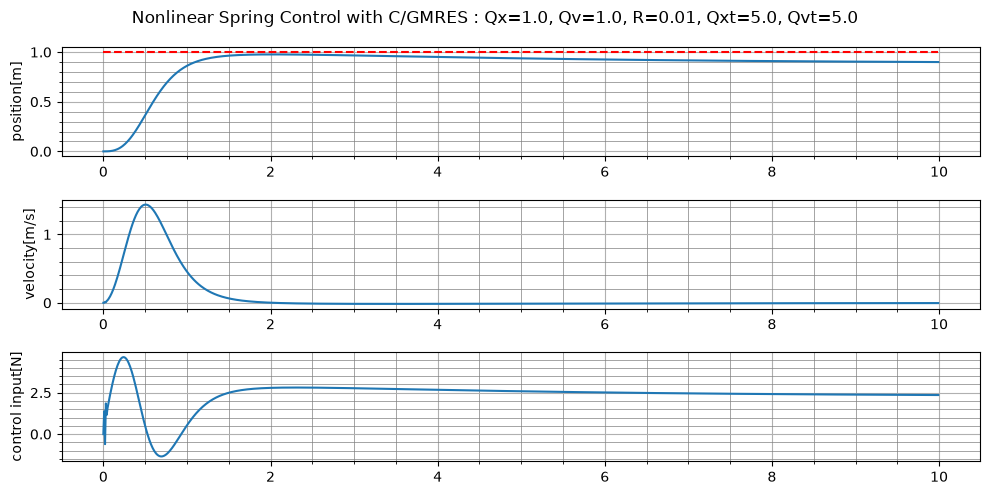

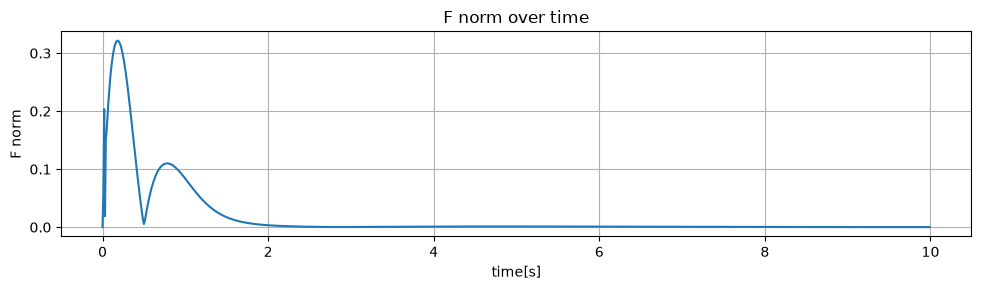

In [5]:
params_1 = Parameters()
params_1.qxt = 5.0
params_1.qvt = 5.0
params_1.qx = 1.0
params_1.qv = 1.0
params_1.r = 0.01
params_1.Tf = 3.0
params_1.eps = 1e-3
params_1.zeta = 10.0

t1_array, x1_array, u1_array , f1_norm_array,_ = calc_simulation(params_1, N=1000)
plot_results(t1_array, x1_array, u1_array, params_1)
plot_f_norm(t1_array, f1_norm_array)

ランニングコストの重みを状態$X$に対しては (Qx, Qv) = 1, 制御入力に対して R=0.01、 
終端コストの重みを状態$X$に対して5程度にすると、状態は一度目標値付近に到達した後、徐々に目標位置から離れる。また、制御入力も徐々に減少する。

停留条件 $F$ のノルムは最初はゼロだが、過渡期ではゼロではない。その後0近傍へ収束する。一方 $F \rightarrow 0$ となって後も位置は目標値と一致していない。

従って、$F=0$ は「目標状態に到達している」ことを意味するのではなく、現在設定した評価関数に対するPMPの停留条件を満たしていることを意味する。

今回はランニングコストに$ru^2/2$ が含まれるため、目標位置を維持するための入力にもコストが生じる。そのため、C/GMRESは位置誤差と制御入力コストの妥協点を選択し、目標位置に対して定常偏差が生じる。

定常偏差を計算で求めてみる。

運動方程式は

$$
m \dot{v} = u - k x - k_3 x^3
$$

定常状態では、$\dot{v} = 0$ であるので、

$$
u = k x + k_3 x^3
$$

ランニングコストは

$$
L = \frac{1}{2}q_x(x - x_{ref})^2 + \frac{1}{2}q_v v^2 + \frac{1}{2} r u^2
$$

定常状態では

$$
L_{ss} = \frac{1}{2}q_x(x - x_{ref})^2 + \frac{1}{2} r (k x + k_3 x^3)^2
$$

よって定常状態では、以下のトレードオフになる。
- $x=x_{ref}$ に近づけたい
- $u = k x + k_3 x^3$ は小さくしたい

$L_{ss}$ を $x$ で微分して $0$ とすると、

$$
\frac{d L_{ss}}{dx} = q_x(x - x_{ref}) + r(k + 3 k_3 x^2)(k x + k_3 x^3)= 0
$$

従って、定常偏差 $x_{ss}$ は上記を満たす$x$ になる。

$ q_x = 1, r = 0.01, k = 1, k_3 = 2, x_{ref} = 1$ を代入すると次のようになる。

$$
(x - 1) + 0.01 (1 + 6 x^2)(x + 2 x^3) = 0
$$

$x=1$を代入すると、

$$
0.01(7)(3) = 0.21
$$

つまり、$x=1$はこの評価関数に対する定常的な最適点ではないと言える。

ニュートン法で解いてみる。

$$
f(x)=(x - 1) + 0.01 (1 + 6 x^2)(x + 2 x^3)
$$

$$
f'(x)= 1 + 0.01(12 x) + 0.01(1+6 x^2)(1 + 6x)
$$

よって、適当な初期値$x_0$を決め

$$
x_{n+1} = x_n - f(x_n)/f'(x_n)
$$

を計算して、$|x_{n+1} - x_n| < e$ と十分小さくなる$x$を探す。

In [6]:

def calc_state_x(x0, x_ref = 1.0, qx=1.0, k=1.0, k3=2.0, r=0.01):

    f = lambda x: qx * (x - x_ref) + r*(k + 3*k3*x**2)*(k *x + k3* x**3)
    df = lambda x: qx + r*(6*k3*x)*(k*x + k3*x**3) + r*(k + 3*k3*x**2)*(k + 9*k3*x**2)

    x=x0
    xn = x - f(x)/df(x)
    while abs(xn - x) > 1e-6:
        x = xn
        xn = x - f(x)/df(x)
    return xn

print(f"state x : {calc_state_x(0.0)*1000}[mm]")
x1_last = x1_array[-1,0]
v1_last = x1_array[-1,1]
u1_last = u1_array[-1]
print(f"x : {x1_last*1000}[mm], v : {v1_last*1000}[mm/s] , u : {u1_last}[N]")

state x : 875.7162674518028[mm]
x : 899.7382078517305[mm], v : -3.713899980705609[mm/s] , u : 2.357264471585236[N]


上記のように、定常偏差は875[mm]で、実際の計算では899[mm]と近い値が出ている。速度もゼロにはなっていないためずれはあるが、定常時には計算した値に近づく。

目標位置になるために必要な制御入力を計算すると

$u_{ref} = k x_{ref} + k_3 x_{ref}^3$ より、以下のように3.0 $[N]$ となる。

In [7]:
u = 1 + 2 * 1**3
print(f"u : {u}[N]")

u : 3[N]


ランニングコストで $u_{ref}$ を考慮すれば次となり、

$$
L = \frac{1}{2}q_x(x - x_{ref})^2 + \frac{1}{2}q_v v^2 + \frac{1}{2} r (u - u_{ref})^2
$$

停留条件 $H_u$ も以下のように変更になる。

$$
H_u = r(u - u_{ref}) + \frac{\lambda_v}{m}
$$

実際に計算は行わないが、偏差を取り扱おうとするとこのようになる。

また

$$
\frac{d L_{ss}}{dx} = q_x(x - x_{ref}) + r(k + 3 k_3 x^2)(k x + k_3 x^3)= 0
$$

より、$q_x, r, k$ を変更するとこで偏差はどれくらい乗るのか計算するこことが出来る。

よって、 $q_x >> r$ のような関係となっていると、定常偏差がほぼなくなるという結果になる。


In [8]:
print(f"{calc_state_x(0.0, qx=1, r=100)*1000}[mm]")

print(f"{calc_state_x(0.0, qx=100, r=1)*1000}[mm]")

print(f"{calc_state_x(0.0, qx=1000, r=0.1)*1000}[mm]")

print(f"{calc_state_x(0.0, qx=1000, r=0.001)*1000}[mm]")


9.893318995894298[mm]
875.7162674518028[mm]
997.9176388566979[mm]
999.9790017849258[mm]


$q_x >> r$ の検証

C/GMRES mean time: 4.174161695642921 [ms]
C/GMRES max time: 74.54609900014475 [ms]
C/GMRES min time: 1.7951059999177232 [ms]


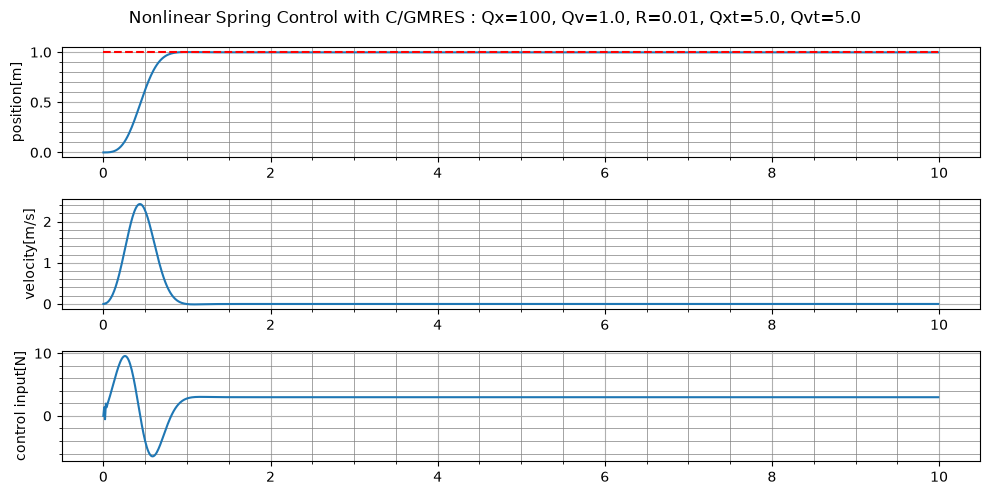

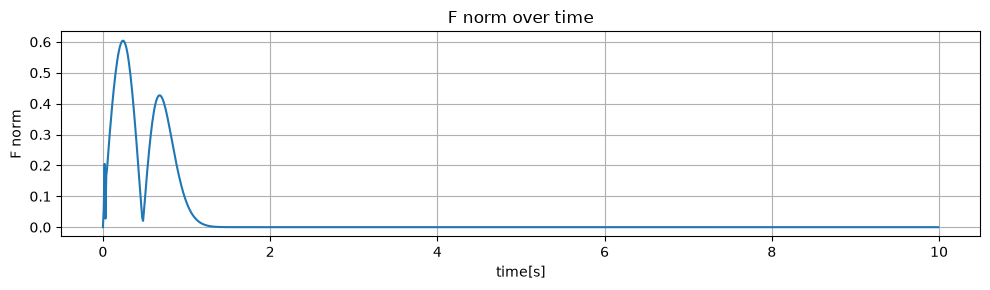

In [9]:
params2 = Parameters()
params2.qxt = 5.0
params2.qvt = 5.0
params2.qx = 100
params2.qv = 1.0
params2.r = 0.01
params2.Tf = 3.0
params2.eps = 1e-3
params2.zeta = 10.0

t2_array, x2_array, u2_array, f2_norm_array,Fs2 = calc_simulation(params2, N=1000)
plot_results(t2_array, x2_array, u2_array, params2)
plot_f_norm(t2_array, f2_norm_array)

In [10]:
print(f"last state x : {x2_array[-1,0]*1000}[mm]")
print(f"last state v : {x2_array[-1,1]*1000}[mm/s]")
print(f"last control input : {u2_array[-1]}[N]")

last state x : 997.9176377040909[mm]
last state v : -3.376660333680029e-07[mm/s]
last control input : 2.9854494642340583[N]


ランニングコストの位置$x$に対する重みQxを100と変更し、rを0.01として qx >> r のようにした場合の応答結果は、位置は目標位置へ近づいている。実際には上記のように997.917[mm]となっている。

制御入力は約3Nとなっており、計算の結果に近い値となっている。

ここから考えられるのは、ある一定期間のコストを計算するランニングコストにおいて、制御入力の重み << 位置の重みとすると、位置誤差を積極的にゼロへ近づけるため、相対的に制御入力は大きくなっていくためと言える。

停留条件 $F$ のノルムは1.8秒程度で収束するまで大きな振幅をとなっている。早い収束を行うために、$F(X,u,t)$の$u$のフィードバックが大きくなるため、$F$のゼロからのずれも大きくなる。

$\zeta$ の大きさにより、$F$ はどのように変化し、またその時の状態、制御入力はどのように変化するのかを検証する。

In [11]:
params3 = Parameters()
params3.qxt = 5.0
params3.qvt = 5.0
params3.qx = 100
params3.qv = 1.0
params3.r = 0.01
params3.Tf = 3.0
params3.eps = 1e-3
# zetaを大きくして、停留条件への追従を強くした場合の応答を確認
params3.zeta = 100.0

t3_array, x3_array, u3_array, f3_norm_array, Fs3 = calc_simulation(params3, N=1000)

# zetaを0にして、停留条件誤差の安定化項を無効にした場合の応答を確認
params3.zeta = 0.0
t4_array, x4_array, u4_array, f4_norm_array, Fs4 = calc_simulation(params3, N=1000)

C/GMRES mean time: 2.71145734847493 [ms]
C/GMRES max time: 8.320111999637447 [ms]
C/GMRES min time: 0.9398589972988702 [ms]
C/GMRES mean time: 2.7495155006178535 [ms]
C/GMRES max time: 5.433656995592173 [ms]
C/GMRES min time: 1.0738889977801591 [ms]


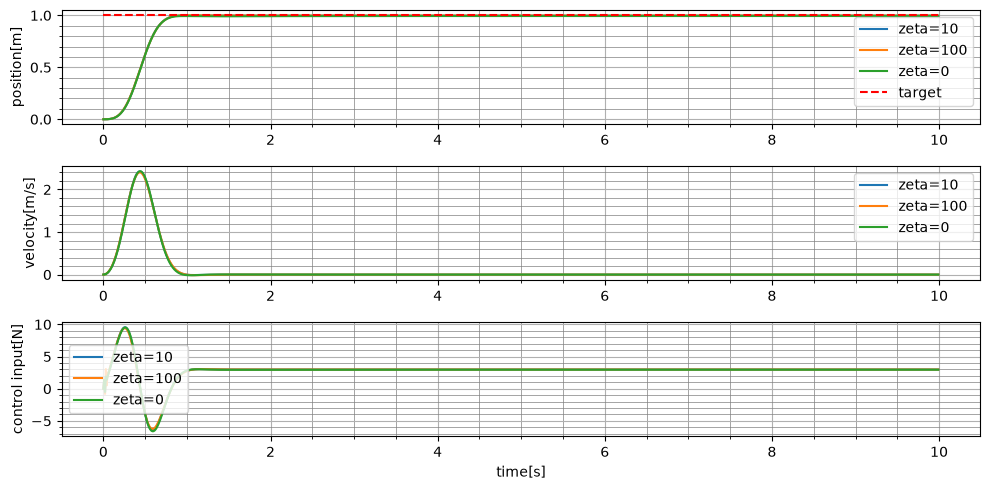

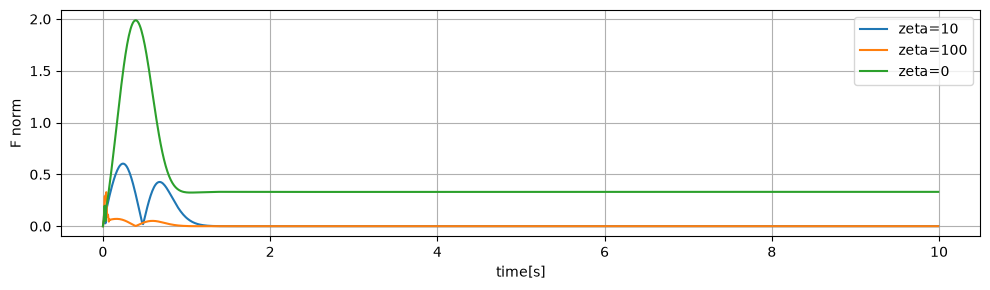

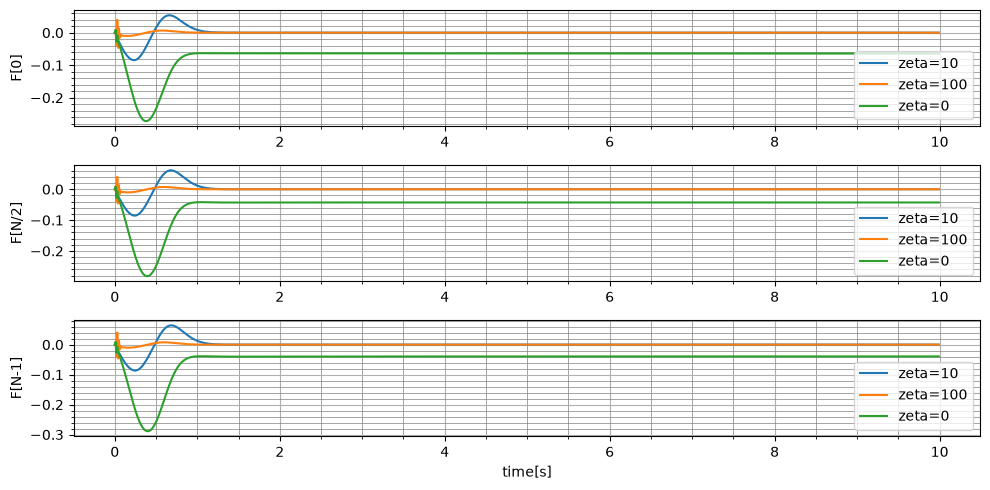

In [12]:
fig, ax = plt.subplots(3,1, figsize=(10,5))

ax[0].plot(t2_array, x2_array[:,0], label='zeta=10')
ax[0].plot(t3_array, x3_array[:,0], label='zeta=100')
ax[0].plot(t4_array, x4_array[:,0], label='zeta=0')
ax[0].hlines(params2.x_target, t2_array[0], t2_array[-1], color='r', linestyle='--', label='target')
ax[0].set_ylabel("position[m]")
ax[0].legend()
ax[1].plot(t2_array, x2_array[:,1], label='zeta=10')
ax[1].plot(t3_array, x3_array[:,1], label='zeta=100')
ax[1].plot(t4_array, x4_array[:,1], label='zeta=0')
ax[1].set_ylabel("velocity[m/s]")
ax[1].legend()
ax[2].plot(t2_array, u2_array, label='zeta=10')
ax[2].plot(t3_array, u3_array, label='zeta=100')
ax[2].plot(t4_array, u4_array, label='zeta=0')
ax[2].set_ylabel("control input[N]")
ax[2].legend()
ax[2].set_xlabel("time[s]")

for i in range(3):
    ax[i].grid()
    ax[i].grid(which="minor", lw=0.5, color='grey')
    ax[i].minorticks_on()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,1, figsize=(10,3))
ax.plot(t2_array, f2_norm_array, label='zeta=10')
ax.plot(t3_array, f3_norm_array, label='zeta=100')
ax.plot(t4_array, f4_norm_array, label='zeta=0')
ax.set_ylabel("F norm")
ax.set_xlabel("time[s]")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(3,1, figsize=(10,5))
ax[0].plot(t2_array, Fs2[0], label='zeta=10')
ax[0].plot(t3_array, Fs3[0], label='zeta=100')
ax[0].plot(t4_array, Fs4[0], label='zeta=0')
ax[0].set_ylabel("F[0]")
ax[1].plot(t2_array, Fs2[1], label='zeta=10')
ax[1].plot(t3_array, Fs3[1], label='zeta=100')
ax[1].plot(t4_array, Fs4[1], label='zeta=0')
ax[1].set_ylabel("F[N/2]")
ax[2].plot(t2_array, Fs2[2], label='zeta=10')
ax[2].plot(t3_array, Fs3[2], label='zeta=100')
ax[2].plot(t4_array, Fs4[2], label='zeta=0')
ax[2].set_ylabel("F[N-1]")
ax[2].set_xlabel("time[s]")
for i in range(3):
    ax[i].grid()
    ax[i].grid(which="minor", lw=0.5, color='grey')
    ax[i].minorticks_on()
    ax[i].legend()
plt.tight_layout()
plt.show()

$\zeta$はGMRESの右辺に渡す $b_k$ で以下の式の計算に用いられる。

$$
b_k = - \frac{F(U(t_k) , X(t_k) + \varepsilon \dot{X}(t_k) , t_k + \varepsilon) - F(U(t_k), X(t_k), t_k)}{\varepsilon} - \zeta F(U(t_k), X(t_k), t_k)
$$

ここで$\zeta$ を大きくすると、$F$の収束は早くなり、小さいと$F$の収束は遅くなる。
また、$\zeta=0$の場合、上記のように一度ずれると"0"へ収束しない。

上記のように$F$の挙動は$\zeta$により変化するが、状態と制御入力の値はほぼ同じ値を示している。

これは$F=0$は、状態が目標値へ到達するための条件ではなく、設定した最適制御問題に対する対流条件であるためである。C/GMRESでは

$$
F(U(t), X(t), t) = 0
$$

を満たす制御入力 $U(t)$ を追跡する。この$F=0$はPMPから得られる最適性の必要条件であり、$F$が0に近いほど、その時刻における制御入力列が停留条件を満たしていることを表す。

停留条件を満たすとは、$U$を微小に変化させたときの評価関数の一次変化が0となることを意味する。
ただし、これは最適解であるための必要条件であり、これだけで最小値であることを保証されるわけではない。

$\zeta$ は

$$
\dot{F} = -\zeta F
$$

となるように停留条件の誤差を0へ収束させるための安定化パラメータであり、評価関数の重みのように制御対象の応答に直接影響するパラメータではない。

今回は $\zeta = 0, 10, 100$ で$F$に大きな違いが生じた。しかし制御対象に入力される制御入力$u_0(t)$はほぼ同じであった。そのため、状態$X(t)$の応答にほとんど差は現れなかった。

ただ、これは$F \neq 0$ でも問題がないというを意味することではない。より複雑な問題や外乱、数値誤差などによって、停留条件からのズレが大きくなった場合、最適性の追跡性能に影響する可能性がある。そのためC/GMRESでは $\zeta > 0 $ とすることで$F=0$ からのずれを抑制する。

上記の計算は運動方程式という等式制約を設定したC/GMRESの結果であった。

次は、不等式制約を考慮してC/GMRESを実施する。